In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd


In [2]:
from tensorflow.keras.optimizers import RMSprop


In [3]:
pathh1=r'M:\CONUS2_DL\training_2020_outlier.csv'
df=pd.read_csv(pathh1)   
    

In [4]:
print(df.describe().T)

                     count        mean         std         min           25%  \
Lat              5387341.0   31.602876    3.849253   20.050000  2.958200e+01   
Lon              5387341.0  -95.221277    9.204895 -110.110000 -1.025500e+02   
Clay             5387341.0    0.238822    0.075370    0.090000  2.100000e-01   
Roughness        5387341.0    3.773951    0.318413    3.250000  3.334000e+00   
temperature      5387341.0  293.820477    8.921571  267.310000  2.866100e+02   
precipitation    5387341.0    0.000249    0.000420    0.000000  2.124500e-07   
LAI              5387341.0    2.190129    1.837048    0.000000  0.000000e+00   
SM               5387341.0    0.219807    0.115251    0.020000  1.194000e-01   
Incidence Angle  5387341.0   30.843848   14.044269    0.008386  2.090400e+01   
Reflectivity     5387341.0  -24.216982    4.089216  -30.000000 -2.752200e+01   
SWF              5387341.0    0.012446    0.035131    0.000000  0.000000e+00   
Day              5387341.0  155.660770  

In [5]:
df['Reflectivity']=df['Reflectivity']-df['Reflectivity'].min()
df['Lon']=df['Lon']+180
df['precipitation']=df['precipitation']*1000
#df['NDVI']=df['NDVI']+abs(df['NDVI'].min())

In [6]:
df=df.drop(['Day','NDVI'],axis=1)

In [7]:
from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler(feature_range=(0, 1))
#Z_scaled = scaler.fit_transform(df)
#Z_scaled2=pd.DataFrame(Z_scaled)
#x=Z_scaled2.iloc[:,[0,1,2,3,4,5,6,8,9,10]]
#y=Z_scaled2.iloc[:,[7,11]]

In [7]:
print(df.head())

      Lat     Lon     Clay  Roughness  temperature  precipitation  LAI  \
0  27.713  81.708  0.23778      3.791       303.60       0.031274  0.0   
1  27.718  81.738  0.23778      3.791       303.60       0.031274  0.0   
2  27.722  81.768  0.23000      3.791       303.47       0.042233  0.0   
3  27.727  81.798  0.23000      3.791       303.47       0.042233  0.0   
4  27.732  81.828  0.23000      3.791       303.47       0.042233  0.0   

        SM  Incidence Angle  Reflectivity       SWF     VOD  
0  0.20557           60.459         5.107  0.000000  0.2605  
1  0.20557           60.452         5.097  0.000000  0.2605  
2  0.20557           60.446         5.043  0.000000  0.2884  
3  0.20942           60.440         5.982  0.000519  0.2884  
4  0.20942           60.434         7.677  0.000519  0.2884  


In [5]:
from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import StandardScaler


# Step 1: Split the dataset into inputs and outputs first
x = df.iloc[:, [0,1,2,3,4,5,6,8,9,10]]
y = df.iloc[:, [7,11]]

# Step 2: Normalize the inputs (x2)
scaler_x = MinMaxScaler(feature_range=(0, 1))
x_scaled = scaler_x.fit_transform(x)

# Step 3: Normalize the outputs (y2) separately
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y)

# Optional: Convert to DataFrame if necessary
x_scaled_df = pd.DataFrame(x_scaled)
y_scaled_df = pd.DataFrame(y_scaled)


In [8]:
from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import StandardScaler


# Step 1: Split the dataset into inputs and outputs first
x = df.iloc[:, [0,1,2,3, 4,5, 8,9]]
y = df.iloc[:, [7,11]]

# Step 2: Normalize the inputs (x2)
scaler_x = MinMaxScaler(feature_range=(0, 1))
x_scaled = scaler_x.fit_transform(x)

# Step 3: Normalize the outputs (y2) separately
scaler_y = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler_y.fit_transform(y)

# Optional: Convert to DataFrame if necessary
x_scaled_df = pd.DataFrame(x_scaled)
y_scaled_df = pd.DataFrame(y_scaled)

In [9]:
print((y_scaled_df.shape))

(5387341, 2)


In [ ]:
# Inverse the normalization for the predictions
y_pred_denormalized = scaler_y.inverse_transform(y_pred_scaled)


# train2

In [10]:
pathh1=r'M:\CONUS2_DL\Validation_outlier_2021_1_3.csv'
df2=pd.read_csv(pathh1)   

In [11]:
df2['Reflectivity']=df2['Reflectivity']-df2['Reflectivity'].min()


In [12]:
df2['Lon']=df2['Lon']+180

In [13]:
#df2['NDVI']=df2['NDVI']+abs(df2['NDVI'].min())

In [14]:
df2['precipitation']=df2['precipitation']*1000

In [13]:
print(df2.describe().T)

                     count        mean        std         min           25%  \
Lat              1248147.0   31.828323   3.718372   20.050000  3.008400e+01   
Lon              1248147.0   85.353193   9.264730   69.890000  7.796000e+01   
Clay             1248147.0    0.238539   0.076616    0.090000  2.100000e-01   
Roughness        1248147.0    3.797541   0.315113    3.250000  3.791000e+00   
temperature      1248147.0  284.921338   6.420141  268.980000  2.800700e+02   
precipitation    1248147.0    0.253054   0.458259    0.000000  2.775600e-14   
LAI              1248147.0    2.017024   1.616262    0.000000  0.000000e+00   
SM               1248147.0    0.252497   0.123570    0.020000  1.357500e-01   
Incidence Angle  1248147.0   31.460456  14.161311    0.073481  2.146300e+01   
Reflectivity     1248147.0    6.204540   4.326575    0.000000  2.713000e+00   
SWF              1248147.0    0.003226   0.005498    0.000000  0.000000e+00   
Day              1248147.0   44.368817  27.699951   

In [15]:
df2=df2.drop(['Day','NDVI'],axis=1)

In [16]:
print(df2.shape)

(1248147, 12)


In [12]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Split the dataset into inputs and outputs first
x2 = df2.iloc[:, [0,1,2,3,4,5,6,8,9,10]]
y2 = df2.iloc[:, [7,11]]

# Step 2: Normalize the inputs (x2)
scaler_x_val = MinMaxScaler(feature_range=(0, 1))
x2_scaled = scaler_x_val.fit_transform(x2)

# Step 3: Normalize the outputs (y2) separately
scaler_y_val = MinMaxScaler(feature_range=(0, 1))
y2_scaled = scaler_y_val.fit_transform(y2)

# Optional: Convert to DataFrame if necessary
x2_scaled_df = pd.DataFrame(x2_scaled)
y2_scaled_df = pd.DataFrame(y2_scaled)


In [17]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Split the dataset into inputs and outputs first
x2 = df2.iloc[:, [0,1,2,3,4,5,8,9]]
y2 = df2.iloc[:, [7,11]]

# Step 2: Normalize the inputs (x2)
scaler_x_val = MinMaxScaler(feature_range=(0, 1))
x2_scaled = scaler_x_val.fit_transform(x2)

# Step 3: Normalize the outputs (y2) separately
scaler_y_val = MinMaxScaler(feature_range=(0, 1))
y2_scaled = scaler_y_val.fit_transform(y2)

# Optional: Convert to DataFrame if necessary
x2_scaled_df = pd.DataFrame(x2_scaled)
y2_scaled_df = pd.DataFrame(y2_scaled)

In [18]:
print(((x2_scaled_df.shape)))

(1248147, 8)


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Create the Sequential model
model = Sequential()

# First hidden layer with 256 neurons, input dimension of 9
model.add(Dense(128, input_dim=8, kernel_initializer='normal', activation='relu'))
model.add(Dropout(0.2))  # Adding dropout to prevent overfitting

# Second hidden layer with 128 neurons
model.add(Dense(64, kernel_initializer='normal', activation='relu'))
model.add(Dropout(0.2))  # Adding dropout to prevent overfitting

# Output layer with 2 neurons for two output features
from tensorflow.keras.regularizers import l2
model.add(Dense(2, kernel_initializer='normal', kernel_regularizer=l2(0.01)))


# Define the optimizer with a learning rate of 0.00001
optimizer = Adam(learning_rate=0.00001)

# Compile the model
model.compile(loss='mean_squared_error', optimizer=optimizer)

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model.fit(x_scaled_df,y_scaled_df, batch_size=128, epochs=200, validation_data=(x2_scaled_df, y2_scaled_df), 
                    callbacks=[early_stopping], verbose=1)


Epoch 1/200
42089/42089 [==============================] - 89s 2ms/step - loss: 0.0232 - val_loss: 0.0147
Epoch 2/200
42089/42089 [==============================] - 95s 2ms/step - loss: 0.0165 - val_loss: 0.0132
Epoch 3/200
42089/42089 [==============================] - 92s 2ms/step - loss: 0.0150 - val_loss: 0.0124
Epoch 4/200
42089/42089 [==============================] - 91s 2ms/step - loss: 0.0141 - val_loss: 0.0119
Epoch 5/200
42089/42089 [==============================] - 92s 2ms/step - loss: 0.0136 - val_loss: 0.0115
Epoch 6/200
42089/42089 [==============================] - 94s 2ms/step - loss: 0.0132 - val_loss: 0.0114
Epoch 7/200
42089/42089 [==============================] - 91s 2ms/step - loss: 0.0130 - val_loss: 0.0112
Epoch 8/200
42089/42089 [==============================] - 91s 2ms/step - loss: 0.0128 - val_loss: 0.0110
Epoch 9/200
42089/42089 [==============================] - 91s 2ms/step - loss: 0.0126 - val_loss: 0.0110
Epoch 10/200
42089/42089 [====================

42089/42089 [==============================] - 106s 3ms/step - loss: 0.0108 - val_loss: 0.0093
Epoch 78/200
42089/42089 [==============================] - 108s 3ms/step - loss: 0.0108 - val_loss: 0.0093
Epoch 79/200
42089/42089 [==============================] - 104s 2ms/step - loss: 0.0108 - val_loss: 0.0093
Epoch 80/200
42089/42089 [==============================] - 105s 3ms/step - loss: 0.0107 - val_loss: 0.0092
Epoch 81/200
42089/42089 [==============================] - 107s 3ms/step - loss: 0.0107 - val_loss: 0.0093
Epoch 82/200
42089/42089 [==============================] - 106s 3ms/step - loss: 0.0107 - val_loss: 0.0092
Epoch 83/200
42089/42089 [==============================] - 106s 3ms/step - loss: 0.0107 - val_loss: 0.0093
Epoch 84/200
42089/42089 [==============================] - 103s 2ms/step - loss: 0.0107 - val_loss: 0.0093
Epoch 85/200
42089/42089 [==============================] - 103s 2ms/step - loss: 0.0107 - val_loss: 0.0093
Epoch 86/200
42089/42089 [===============

In [29]:
import shap

# compute SHAP values


In [31]:

# Convert DataFrame to NumPy array
x_numpy = x3_scaled_df.to_numpy()  # Convert the DataFrame 'x' to a NumPy array

# Randomly select 1000 samples for background data from x
background = x_numpy[np.random.choice(x_numpy.shape[0], 5000, replace=False)]

# Initialize the SHAP explainer using the background data
explainer = shap.DeepExplainer(model, background)

# Select a test subset (can be different from background data)
test_data = x_numpy[:5000, :]  # First 4000 rows as test data

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(test_data)


Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


In [28]:
print(type(x2_scaled_df))

<class 'pandas.core.frame.DataFrame'>


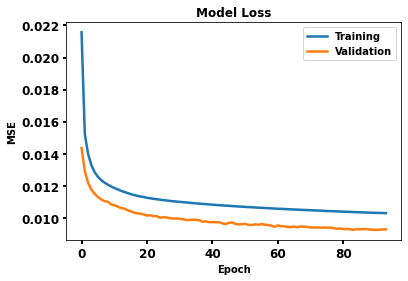

In [31]:
from matplotlib import pyplot as plt

# Plot training and validation loss with thicker lines
plt.plot(history.history['loss'], label='Training', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Validation', linewidth=2.5)

# Add legend with bold font
plt.legend(prop={'weight': 'bold'})

# Set title and labels with bold font
plt.title('Model Loss', fontweight='bold')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('MSE', fontweight='bold')

# Bold the numbers on the axes
plt.tick_params(axis='both', which='major', labelsize=12, width=2)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Show the plot
plt.show()



In [21]:

pathh3=r'M:\CONUS2_DL\test_outlier_2021_4_5.csv'
df3=pd.read_csv(pathh3)   


In [19]:
print(df3.describe().T)

                    count        mean        std        min           25%  \
Lat              841985.0   31.781591   3.743002   20.05000  2.984900e+01   
Lon              841985.0  -95.790147   9.062592 -110.11000 -1.027700e+02   
Clay             841985.0    0.237479   0.073063    0.09000  2.100000e-01   
Roughness        841985.0    3.764800   0.316981    3.25000  3.334000e+00   
temperature      841985.0  294.581764   5.378415  271.99000  2.908000e+02   
precipitation    841985.0    0.000308   0.000515    0.00000  9.112400e-07   
LAI              841985.0    2.116731   1.941792    0.00000  4.440900e-16   
SM               841985.0    0.189797   0.108385    0.02000  9.558800e-02   
Incidence Angle  841985.0   30.674885  14.059094    0.25425  2.059100e+01   
Reflectivity     841985.0  -24.255573   4.125349  -30.00000 -2.757800e+01   
SWF              841985.0    0.002124   0.003766    0.00000  0.000000e+00   
Day              841985.0  123.562650  14.514291   99.00000  1.100000e+02   

In [22]:
df3['Reflectivity']=df3['Reflectivity']-df3['Reflectivity'].min()
df3['Lon']=df3['Lon']+180
df3['precipitation']=df3['precipitation']*1000
#df3['NDVI']=df3['NDVI']+abs(df3['NDVI'].min())




In [24]:
df3=df3.drop(['Day','NDVI'],axis=1)

In [25]:
print(df3.head())

      Lat    Lon  Clay  Roughness  temperature  precipitation     LAI  \
0  33.402  75.45  0.24      3.334       293.84       0.000764  3.5021   
1  33.403  75.48  0.24      3.791       294.61       0.000573  4.9591   
2  33.404  75.51  0.24      3.334       294.61       0.000573  4.9591   
3  33.404  75.54  0.24      3.334       294.61       0.000573  4.9591   
4  33.405  75.58  0.24      3.334       294.79       0.000191  2.5011   

         SM  Incidence Angle  Reflectivity      SWF      VOD  
0  0.065738           23.149         8.665  0.00175  0.16099  
1  0.065738           23.169         8.281  0.00175  0.16099  
2  0.065738           23.188         9.163  0.00175  0.18941  
3  0.065254           23.208        10.942  0.00175  0.18941  
4  0.065254           23.227        10.995  0.00175  0.18941  


In [19]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Split the dataset into inputs and outputs first
x3 = df3.iloc[:, [0,1,2,3,4,5,6,8,9,10]]
y3 = df3.iloc[:, [7,11]]

# Step 2: Normalize the inputs (x2)
scaler_x_test = MinMaxScaler(feature_range=(0, 1))
x3_scaled = scaler_x_test.fit_transform(x3)

# Step 3: Normalize the outputs (y2) separately
scaler_y_test = MinMaxScaler(feature_range=(0, 1))
y3_scaled = scaler_y_test.fit_transform(y3)

# Optional: Convert to DataFrame if necessary
x3_scaled_df = pd.DataFrame(x3_scaled)
y3_scaled_df = pd.DataFrame(y3_scaled)

In [26]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Split the dataset into inputs and outputs first
x3 = df3.iloc[:, [0,1,2,3, 4,5, 8,9]]
y3 = df3.iloc[:, [7,11]]

# Step 2: Normalize the inputs (x2)
scaler_x_test = MinMaxScaler(feature_range=(0, 1))
x3_scaled = scaler_x_test.fit_transform(x3)

# Step 3: Normalize the outputs (y2) separately
scaler_y_test = MinMaxScaler(feature_range=(0, 1))
y3_scaled = scaler_y_test.fit_transform(y3)

# Optional: Convert to DataFrame if necessary
x3_scaled_df = pd.DataFrame(x3_scaled)
y3_scaled_df = pd.DataFrame(y3_scaled)

In [43]:
print(df3.shape)

(6535701, 12)


In [49]:
from scipy.stats.stats import pearsonr 
ypred=model.predict(x2_scaled_df)



39005/39005 [==============================] - 25s 634us/step


In [50]:
# Inverse the normalization for the predictions
y_pred_denormalized = scaler_y.inverse_transform(ypred)

In [51]:
y_pred_denormalized2=pd.DataFrame(y_pred_denormalized)

In [48]:
import numpy as np
import pandas as pd

# Assuming ypred is your NumPy array
#y3_inverse_df = np.array(y3_inverse_df)

# Convert the NumPy array to a DataFrame
y3_inverse_df = pd.DataFrame(y_pred_denormalized, columns=['Column1', 'Column2'])  # Name columns as needed

# Save the DataFrame to a CSV file
y_pred_denormalized2.to_csv('second_ANN_inverse_df.csv', index=False)

print("ypred saved to 'ypred_output.csv'")


ypred saved to 'ypred_output.csv'


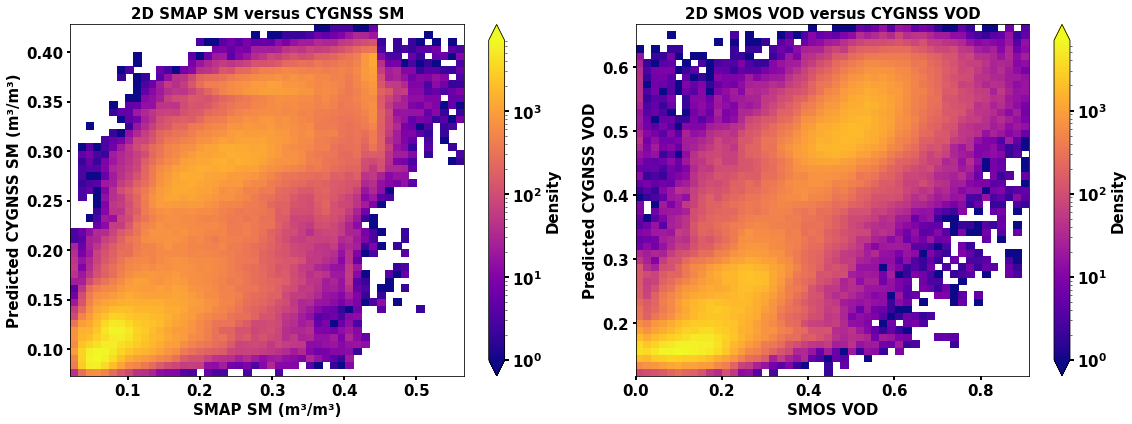

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# Create a figure with two subplots, sharing x and y axes
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: 2D histogram for SMAP SM versus CYGNSS SM
hist1 = axs[0].hist2d(y3.iloc[:, 0], y_pred_denormalized2.iloc[:, 0], bins=50, cmap='plasma', norm=LogNorm())

# Set the colorbar for the first subplot
cbar1 = fig.colorbar(hist1[3], ax=axs[0], extend='both')
cbar1.set_label('Density', fontweight='bold', fontsize=15)
cbar1.ax.tick_params(labelsize=15, labelcolor='black', width=2)
for label in cbar1.ax.get_yticklabels():
    label.set_fontweight('bold')

# Set titles and labels for the first subplot
axs[0].set_title('2D SMAP SM versus CYGNSS SM', fontweight='bold', fontsize=15)
axs[0].set_xlabel('SMAP SM (m³/m³)', fontweight='bold', fontsize=15)
axs[0].set_ylabel('Predicted CYGNSS SM (m³/m³)', fontweight='bold', fontsize=15)

# Adjust tick parameters for the first subplot
axs[0].tick_params(axis='both', which='major', labelsize=15, labelcolor='black', width=2)
for label in axs[0].get_xticklabels() + axs[0].get_yticklabels():
    label.set_fontweight('bold')

# Second subplot: 2D histogram for SMOS VOD versus CYGNSS VOD
hist2 = axs[1].hist2d(y3.iloc[:, 1], y_pred_denormalized2.iloc[:, 1], bins=50, cmap='plasma', norm=LogNorm())

# Set the colorbar for the second subplot
cbar2 = fig.colorbar(hist2[3], ax=axs[1], extend='both')
cbar2.set_label('Density', fontweight='bold', fontsize=15)
cbar2.ax.tick_params(labelsize=15, labelcolor='black', width=2)
for label in cbar2.ax.get_yticklabels():
    label.set_fontweight('bold')

# Set titles and labels for the second subplot
axs[1].set_title('2D SMOS VOD versus CYGNSS VOD', fontweight='bold', fontsize=15)
axs[1].set_xlabel('SMOS VOD', fontweight='bold', fontsize=15)
axs[1].set_ylabel('Predicted CYGNSS VOD', fontweight='bold', fontsize=15)

# Adjust tick parameters for the second subplot
axs[1].tick_params(axis='both', which='major', labelsize=15, labelcolor='black', width=2)
for label in axs[1].get_xticklabels() + axs[1].get_yticklabels():
    label.set_fontweight('bold')

# Show the combined plot
plt.tight_layout()
plt.show()


In [71]:
import shap
import numpy as np

# Convert DataFrame to NumPy array
x_numpy = x_scaled_df.to_numpy()  # Convert the DataFrame 'x' to a NumPy array

# Randomly select 1000 samples for background data from x
background = x_numpy[np.random.choice(x_numpy.shape[0], 1000, replace=False)]

# Initialize the SHAP explainer using the background data
explainer = shap.DeepExplainer(model, background)

# Select a test subset (can be different from background data)
test_data = x_numpy[:4000, :]  # First 4000 rows as test data

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(test_data)




Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Instructions for updating:
Simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: module 'gast' has no attribute 'Index'
To silence this warning, decorate the function with @tf.auto

In [200]:
print(type(shap_values))

<class 'shap._explanation.Explanation'>


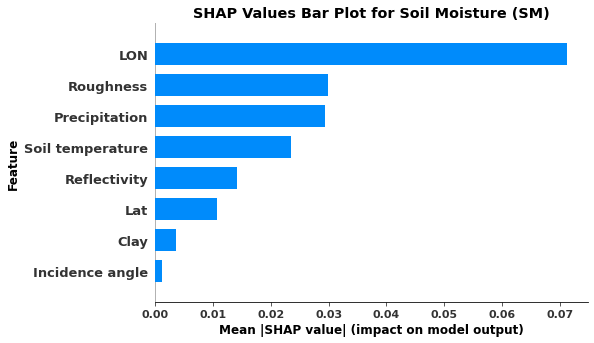

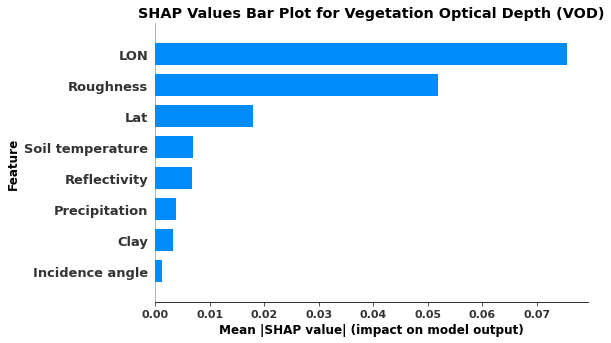

IndexError: index 4398 is out of bounds for axis 0 with size 4000

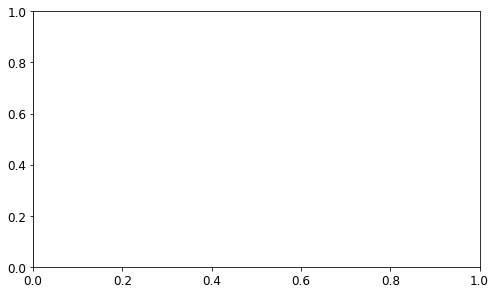

In [32]:
import shap
import matplotlib.pyplot as plt
import matplotlib

# Your custom feature names
column_names = ['Lat', 'LON', 'Clay', 'Roughness', 'Soil temperature', 'Precipitation',
                'Incidence angle', 'Reflectivity']

# Make all text bold in the plot
bold_font = {'fontweight': 'bold'}
plt.rcParams.update({'font.size': 12, 'axes.labelweight': 'bold', 'axes.titleweight': 'bold'})

# Assuming two outputs: Soil Moisture (SM) and Vegetation Optical Depth (VOD)
shap_values_sm = shap_values[0]  # SHAP values for SM
shap_values_vod = shap_values[1]  # SHAP values for VOD

# Function to apply bold to tick labels
def bold_ticks(ax):
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):
        label.set_fontweight('bold')

# Plot SHAP values for Soil Moisture (SM) - Bar plot
shap.summary_plot(shap_values_sm, features=x_scaled_df[:4000], feature_names=column_names, plot_type="bar", show=False)
plt.title("SHAP Values Bar Plot for Soil Moisture (SM)", fontweight='bold')
plt.xlabel("Mean |SHAP value| (impact on model output)", fontsize=12, fontweight='bold')
plt.ylabel("Feature", fontsize=12, fontweight='bold')
bold_ticks(plt.gca())  # Make tick labels bold
plt.show()

# Plot SHAP values for Vegetation Optical Depth (VOD) - Bar plot
shap.summary_plot(shap_values_vod, features=x_scaled_df[:4000], feature_names=column_names, plot_type="bar", show=False)
plt.title("SHAP Values Bar Plot for Vegetation Optical Depth (VOD)", fontweight='bold')
plt.xlabel("Mean |SHAP value| (impact on model output)", fontsize=12, fontweight='bold')
plt.ylabel("Feature", fontsize=12, fontweight='bold')
bold_ticks(plt.gca())  # Make tick labels bold
plt.show()

# Plot SHAP values for Soil Moisture (SM) - Beeswarm plot
shap.summary_plot(shap_values_sm, features=x_scaled_df[:4000], feature_names=column_names, plot_type="dot", show=False)  # Default plot type is "dot" (beeswarm)
plt.title("SHAP Values Beeswarm Plot for Soil Moisture (SM)", fontweight='bold')
plt.xlabel("SHAP value (impact on model output)", fontsize=12, fontweight='bold')
bold_ticks(plt.gca())  # Make tick labels bold
plt.show()

# Plot SHAP values for Vegetation Optical Depth (VOD) - Beeswarm plot
shap.summary_plot(shap_values_vod, features=x_scaled_df[:4000], feature_names=column_names, plot_type="dot", show=False)  # Default plot type is "dot" (beeswarm)
plt.title("SHAP Values Beeswarm Plot for Vegetation Optical Depth (VOD)", fontweight='bold')
plt.xlabel("SHAP value (impact on model output)", fontsize=12, fontweight='bold')
bold_ticks(plt.gca())  # Make tick labels bold
plt.show()


In [205]:
print((shap_values))

AttributeError: 'list' object has no attribute 'shape'

In [88]:
D=np.array(y2)-y_pred_denormalized2
print(np.sqrt((np.square(D)).mean()))


0    0.052258
1    0.083167
dtype: float64


In [ ]:
# print(((np.square(D)).mean()))

In [239]:
print(type(y2))

<class 'pandas.core.frame.DataFrame'>


In [246]:
print(np.sqrt(np.square(0.1002)-np.square(-0.0247)))

0.09710792964531784


In [89]:

print((((D)).mean()))

0    0.001706
1   -0.016767
dtype: float64


In [44]:
import numpy as np

# Convert ypred_inverse_df to a DataFrame if necessary
#ypred_inverse_df = pd.DataFrame(ypred_inverse_df)

# Calculate correlation between the first columns (SM)
corr_first_col = np.corrcoef(y_pred_denormalized2.iloc[:, 0], y3.iloc[:, 0])[0, 1]

# Calculate correlation between the second columns (VOD)
corr_second_col = np.corrcoef(y_pred_denormalized2.iloc[:, 1], y3.iloc[:, 1])[0, 1]

# Display the results
print(f"Correlation coefficient for the first column (SM): {corr_first_col}")
print(f"Correlation coefficient for the second column (VOD): {corr_second_col}")





Correlation coefficient for the first column (SM): 0.8241269647687444
Correlation coefficient for the second column (VOD): 0.8689548705417729


In [295]:
#corr_first_col = np.corrcoef(ypred_inverse_df[:, 0], y3_inverse_df[:, 0])[0, 1]
print((ypred_inverse_df.shape))

(841985, 2)


In [1]:
import numpy as np
print(np.__version__)


1.22.0


In [264]:
!pip install numpy==1.22


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.3.0 requires gast==0.3.3, but you have gast 0.4.0 which is incompatible.
tensorflow 2.3.0 requires numpy<1.19.0,>=1.16.0, but you have numpy 1.22.0 which is incompatible.
tensorflow 2.3.0 requires scipy==1.4.1, but you have scipy 1.6.1 which is incompatible.



  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4


In [153]:
# Create model with two hidden layers, 8 neurons each, 11 input features, and 2 output features
model = Sequential()
model.add(Dense(128, input_dim=11, kernel_initializer='normal', activation='relu'))  # First hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Second hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(64, kernel_initializer='normal', activation='relu'))  # Second hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(2, kernel_initializer='normal'))  # Output layer with 2 neurons for two output features

# Define the optimizer with a learning rate of 0.0001
optimizer = Adam(learning_rate=0.0001)

# Compile model
model.compile(loss='mean_squared_error', optimizer=optimizer)

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model.fit(x, y, batch_size=256, epochs=200, validation_data=(x2, y2), 
                    callbacks=[early_stopping], verbose=1)

Epoch 1/200
21664/21664 [==============================] - 36s 2ms/step - loss: 0.0148 - val_loss: 0.0118
Epoch 2/200
21664/21664 [==============================] - 35s 2ms/step - loss: 0.0114 - val_loss: 0.0110
Epoch 3/200
21664/21664 [==============================] - 36s 2ms/step - loss: 0.0109 - val_loss: 0.0110
Epoch 4/200
21664/21664 [==============================] - 35s 2ms/step - loss: 0.0107 - val_loss: 0.0109
Epoch 5/200
21664/21664 [==============================] - 35s 2ms/step - loss: 0.0105 - val_loss: 0.0109
Epoch 6/200
21664/21664 [==============================] - 35s 2ms/step - loss: 0.0104 - val_loss: 0.0105
Epoch 7/200
21664/21664 [==============================] - 36s 2ms/step - loss: 0.0104 - val_loss: 0.0105
Epoch 8/200
21664/21664 [==============================] - 35s 2ms/step - loss: 0.0103 - val_loss: 0.0105
Epoch 9/200
21664/21664 [==============================] - 35s 2ms/step - loss: 0.0103 - val_loss: 0.0106
Epoch 10/200
21664/21664 [====================

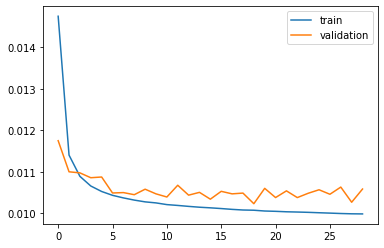

In [154]:
from matplotlib import pyplot
pyplot.plot(history.history ['loss'], label='train')
pyplot.plot(history.history ['val_loss'], label='validation')
pyplot.legend()
pyplot.show()

In [149]:
# Create model with two hidden layers, 8 neurons each, 11 input features, and 2 output features
model = Sequential()
model.add(Dense(256, input_dim=11, kernel_initializer='normal', activation='relu'))  # First hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(64, kernel_initializer='normal', activation='relu'))  # Second hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(64, kernel_initializer='normal', activation='relu'))  # Second hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(64, kernel_initializer='normal', activation='relu'))  # Second hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(2, kernel_initializer='normal'))  # Output layer with 2 neurons for two output features

# Define the optimizer with a learning rate of 0.0001
optimizer = Adam(learning_rate=0.0001)

# Compile model
model.compile(loss='mean_squared_error', optimizer=optimizer)

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model.fit(x, y, batch_size=128, epochs=300, validation_data=(x2, y2), 
                    callbacks=[early_stopping], verbose=1)

Epoch 1/300
43327/43327 [==============================] - 78s 2ms/step - loss: 0.0140 - val_loss: 0.0113
Epoch 2/300
43327/43327 [==============================] - 82s 2ms/step - loss: 0.0114 - val_loss: 0.0110
Epoch 3/300
43327/43327 [==============================] - 77s 2ms/step - loss: 0.0111 - val_loss: 0.0107
Epoch 4/300
43327/43327 [==============================] - 76s 2ms/step - loss: 0.0109 - val_loss: 0.0108
Epoch 5/300
43327/43327 [==============================] - 80s 2ms/step - loss: 0.0108 - val_loss: 0.0107
Epoch 6/300
43327/43327 [==============================] - 77s 2ms/step - loss: 0.0107 - val_loss: 0.0106
Epoch 7/300
43327/43327 [==============================] - 79s 2ms/step - loss: 0.0106 - val_loss: 0.0106
Epoch 8/300
43327/43327 [==============================] - 74s 2ms/step - loss: 0.0105 - val_loss: 0.0104
Epoch 9/300
43327/43327 [==============================] - 78s 2ms/step - loss: 0.0105 - val_loss: 0.0104
Epoch 10/300
43327/43327 [====================

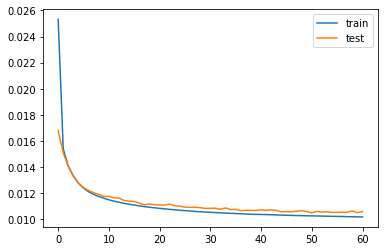

In [152]:
from matplotlib import pyplot
pyplot.plot(history.history ['loss'], label='train')
pyplot.plot(history.history ['val_loss'], label='test')
pyplot.legend()
pyplot.show()

## saving tne model

In [106]:
# Save the entire model
model.save('my_model.h5')  # Save model as an .h5 file


## loading the model

In [111]:
# Load the entire model
from tensorflow.keras.models import load_model

model = load_model('my_model.h5')  # Load the saved model


## new model

In [107]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Create a new model
model = Sequential()
model.add(Dense(256, input_dim=11, activation='relu', kernel_regularizer=l2(0.01)))  # First hidden layer
model.add(Dropout(0.3))  # Adding dropout
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))  # Second hidden layer
model.add(Dropout(0.3))  # Adding dropout
model.add(Dense(2))  # Output layer with 2 neurons

# Compile the model with Adam optimizer and a higher learning rate
optimizer = Adam(learning_rate=0.0001)
model.compile(loss='mean_squared_error', optimizer=optimizer)

# Callbacks: Reduce learning rate and early stopping
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(x, y, batch_size=64, epochs=300, validation_data=(x2, y2), 
                    callbacks=[reduce_lr, early_stopping], verbose=1)

Epoch 1/300
86654/86654 [==============================] - 98s 1ms/step - loss: 0.0299 - val_loss: 0.0191
Epoch 2/300
86654/86654 [==============================] - 98s 1ms/step - loss: 0.0165 - val_loss: 0.0180
Epoch 3/300
86654/86654 [==============================] - 96s 1ms/step - loss: 0.0156 - val_loss: 0.0169
Epoch 4/300
86654/86654 [==============================] - 96s 1ms/step - loss: 0.0151 - val_loss: 0.0166
Epoch 5/300
86654/86654 [==============================] - 96s 1ms/step - loss: 0.0148 - val_loss: 0.0160
Epoch 6/300
86654/86654 [==============================] - 96s 1ms/step - loss: 0.0146 - val_loss: 0.0160
Epoch 7/300
86654/86654 [==============================] - 96s 1ms/step - loss: 0.0145 - val_loss: 0.0160
Epoch 8/300
86654/86654 [==============================] - 95s 1ms/step - loss: 0.0144 - val_loss: 0.0164
Epoch 9/300
86654/86654 [==============================] - 96s 1ms/step - loss: 0.0143 - val_loss: 0.0154
Epoch 10/300
86654/86654 [====================

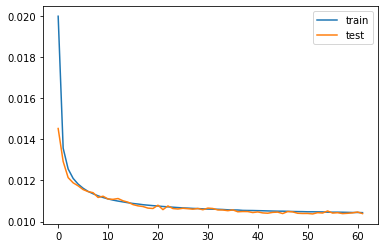

In [114]:
from matplotlib import pyplot
pyplot.plot(history.history ['loss'], label='train')
pyplot.plot(history.history ['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [66]:
# Create model with three hidden layers, 8 neurons each, 11 input features, and 2 output features
model = Sequential()
model.add(Dense(64, input_dim=11, kernel_initializer='normal', activation='relu'))  # First hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(64, kernel_initializer='normal', activation='relu'))  # Second hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(32, kernel_initializer='normal', activation='relu'))  # Third hidden layer with 8 neurons
model.add(Dropout(0.4))  # Adding dropout to prevent overfitting
model.add(Dense(2, kernel_initializer='normal'))  # Output layer with 2 neurons for two output features

# Define the optimizer with a learning rate of 0.0001
optimizer = Adam(learning_rate=0.0001)

# Compile model
model.compile(loss='mean_squared_error', optimizer=optimizer)

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model.fit (x, y, batch_size=30, epochs=200, validation_data=(x2, y2), 
                    callbacks=[early_stopping], verbose=1)


Epoch 1/200
184861/184861 [==============================] - 122s 659us/step - loss: 0.0146 - val_loss: 0.0122
Epoch 2/200
184861/184861 [==============================] - 122s 662us/step - loss: 0.0129 - val_loss: 0.0117
Epoch 3/200
184861/184861 [==============================] - 124s 669us/step - loss: 0.0126 - val_loss: 0.0115
Epoch 4/200
184861/184861 [==============================] - 126s 679us/step - loss: 0.0125 - val_loss: 0.0115
Epoch 5/200
184861/184861 [==============================] - 128s 693us/step - loss: 0.0125 - val_loss: 0.0115
Epoch 6/200
184861/184861 [==============================] - 126s 684us/step - loss: 0.0124 - val_loss: 0.0114
Epoch 7/200
184861/184861 [==============================] - 124s 670us/step - loss: 0.0124 - val_loss: 0.0115
Epoch 8/200
184861/184861 [==============================] - 124s 668us/step - loss: 0.0123 - val_loss: 0.0115
Epoch 9/200
184861/184861 [==============================] - 122s 662us/step - loss: 0.0123 - val_loss: 0.0115
E

KeyboardInterrupt: 

In [50]:
# Create model with four hidden layers, 8 neurons each, 11 input features, and 2 output features
model = Sequential()
model.add(Dense(256, input_dim=11, kernel_initializer='normal', activation='relu'))  # First hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(256, kernel_initializer='normal', activation='relu'))  # Second hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(256, kernel_initializer='normal', activation='relu'))  # Third hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(256, kernel_initializer='normal', activation='relu'))  # Fourth hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(2, kernel_initializer='normal'))  # Output layer with 2 neurons for two output features

# Define the optimizer with a learning rate of 0.0001
optimizer = Adam(learning_rate=0.001)

# Compile model
model.compile(loss='mean_squared_error', optimizer=optimizer)

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model.fit(x, y, batch_size=20, epochs=200, validation_data=(x2, y2), 
                    callbacks=[early_stopping], verbose=1)


Epoch 1/200
277291/277291 [==============================] - 485s 2ms/step - loss: 0.0110 - val_loss: 0.0109
Epoch 2/200
277291/277291 [==============================] - 485s 2ms/step - loss: 0.0108 - val_loss: 0.0114
Epoch 3/200
111197/277291 [===========>..................] - ETA: 4:41 - loss: 0.0109

KeyboardInterrupt: 

In [59]:
# Create model with five hidden layers, 8 neurons each, 11 input features, and 2 output features
model = Sequential()
model.add(Dense(128, input_dim=11, kernel_initializer='normal', activation='relu'))  # First hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Second hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Third hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Fourth hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Fifth hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Fifth hidden layer with 8 neurons
model.add(Dropout(0.3))  # Adding dropout to prevent overfitting
model.add(Dense(2, kernel_initializer='normal'))  # Output layer with 2 neurons for two output features

# Define the optimizer with a learning rate of 0.0001
optimizer = Adam(learning_rate=0.001)

# Compile model
model.compile(loss='mean_squared_error', optimizer=optimizer)

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model.fit(x, y, batch_size=40, epochs=50, validation_data=(x2, y2), 
                    callbacks=[early_stopping], verbose=1)


Epoch 1/50
136403/138646 [============================>.] - ETA: 3s - loss: 0.0114

KeyboardInterrupt: 

In [ ]:
# Create model with five hidden layers, 8 neurons each, 11 input features, and 2 output features
model = Sequential()
model.add(Dense(128, input_dim=11, kernel_initializer='normal', activation='relu'))  # First hidden layer with 8 neurons
model.add(Dropout(0.1))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Second hidden layer with 8 neurons
model.add(Dropout(0.1))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Third hidden layer with 8 neurons
model.add(Dropout(0.1))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Fourth hidden layer with 8 neurons
model.add(Dropout(0.1))  # Adding dropout to prevent overfitting
model.add(Dense(128, kernel_initializer='normal', activation='relu'))  # Fifth hidden layer with 8 neurons
model.add(Dropout(0.1))  # Adding dropout to prevent overfitting
model.add(Dense(2, kernel_initializer='normal'))  # Output layer with 2 neurons for two output features

# Define the optimizer with a learning rate of 0.0001
optimizer = Adam(learning_rate=0.0001)

# Compile model
model.compile(loss='mean_squared_error', optimizer=optimizer)

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
history = model.fit(x, y, batch_size=20, epochs=200, validation_data=(x2, y2), 
                    callbacks=[early_stopping], verbose=1)